# 03 JAX 原生接口：把定价当作一个纯函数

`MonteCarloEngine.pricer(n_paths)` 返回 `f(params) -> pv[n_payoffs]`。它是一个纯函数，可以自由组合 JAX 的变换：

| 变换 | 用途 |
|---|---|
| `jax.jit` | 编译一次，重复调用 |
| `jax.grad` / `jax.jacrev` | 反向模式：多个输入的 Greeks，多个 payoff 的完整雅可比 |
| `jax.jacfwd` / `jax.jvp` | 前向模式：只关心少数几个输入（例如只要 delta） |
| `jax.hessian` | 二阶量（gamma） |
| `jax.vmap` / `jax.lax.map` | 一次算一整条 spot 曲线、一批产品常量或一组情景 |

最后两节展示更多 payoff 写法（亚式期权、延迟支付）和逐路径诊断 `path_payoffs`。

In [1]:
import os

import dal_jax as dj

# Split the CPU into virtual devices so Monte Carlo blocks run in parallel.
# JAX only accepts this before its first operation, so keep it at the top.
dj.config.configure(num_cpu_devices=min(8, os.cpu_count() or 1))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from nbtools import AQUA, BLUE, MUTED, ORANGE, apply_style, label_end, show_table

try:
    import dal  # dal-python, only used for side-by-side comparisons
except ImportError:
    dal = None

apply_style()
print(f"jax {jax.__version__}: {len(jax.devices())} x {jax.devices()[0].platform} device(s); dal-python: {dal is not None}")

starting DAL with: 32 threads.
use AAD framework: AADET
starting initialization global data ...
finished initialization all the global information.
jax 0.11.2: 8 x cpu device(s); dal-python: True


## 1. 一个产品，三个 payoff

一个 `PathProduct` 可以同时返回多个 payoff。这里在同一批路径上算看涨、看跌和远期。
fuzzy 模式下，`max(x, 0)` 换成一个 C¹ 的平滑版本（导数正好是 CSpr），宽度取 `ctx.smooth`，第 4 节算 gamma 时会用到。

In [2]:
from jax.scipy.stats import norm

SPOT, VOL, RATE, DIV, STRIKE, T = 100.0, 0.2, 0.03, 0.01, 100.0, 1.0


def smooth_max0(x, eps):
    """C1 version of max(x, 0) whose derivative is CSpr(x, eps)."""
    half = 0.5 * eps
    return jnp.where(x < -half, 0.0, jnp.where(x > half, x, (x + half) ** 2 / (2.0 * eps)))


def payoffs(params, scenario, ctx):
    k = params["script"]["STRIKE"]
    st, df = scenario.spot[-1], 1.0 / scenario.numeraire[-1]
    positive = (lambda x: smooth_max0(x, ctx.smooth)) if ctx.fuzzy else (lambda x: jnp.maximum(x, 0.0))
    return jnp.stack([positive(st - k) * df, positive(k - st) * df, st * df])


product = dj.PathProduct(timeline=(T,), payoff=payoffs, payoff_names=("call", "put", "forward"), script_params={"STRIKE": STRIKE})
model = dj.BlackScholes(spot=SPOT, vol=VOL, rate=RATE, div=DIV)
engine = dj.MonteCarloEngine(product, model, dj.MonteCarloSettings(smooth=2.0))
params = engine.default_params()

N_PATHS = 2**18
f = jax.jit(engine.pricer(N_PATHS))  # exact mode
call, put, forward = (float(v) for v in f(params))
print(f"call = {call:.6f}, put = {put:.6f}, forward = {forward:.6f}")
print(f"put-call parity: call - put - (forward - K e^(-rT)) = {call - put - (forward - STRIKE * np.exp(-RATE * T)):.2e}")

call = 8.827018, put = 6.866993, forward = 99.004578
put-call parity: call - put - (forward - K e^(-rT)) = -7.99e-15


看涨减看跌在每条路径上都正好等于远期减行权价，所以平价关系只差浮点误差。

## 2. `jax.jacrev`：多个 payoff 的完整雅可比

参数 pytree 有 5 个叶子（4 个模型参数加 `STRIKE`），一次反向模式就得到 3 × 5 的雅可比。

In [3]:
jacobian = jax.jit(jax.jacrev(f))(params)
labels = [("model", k) for k in model.param_labels] + [("script", "STRIKE")]
show_table(
    ["payoff"] + [f"d_{name}" for _, name in labels],
    [[payoff] + [float(jacobian[group][name][i]) for group, name in labels] for i, payoff in enumerate(engine.payoff_names)],
    fmt="{:.5f}",
)

| payoff | d_spot | d_vol | d_rate | d_div | d_STRIKE |
|:---|---:|---:|---:|---:|---:|
| call | 0.57349 | 38.71286 | 48.52228 | -57.34929 | -0.48522 |
| put | -0.41655 | 38.71549 | -48.52228 | 41.65528 | 0.48522 |
| forward | 0.99005 | -0.00263 | 0.00000 | -99.00458 | 0.00000 |

## 3. `jax.jacfwd`：只要 delta

只对一个输入求导时，前向模式更省：把现价单独拿出来当作函数的自变量即可。

In [4]:
def with_spot(spot):
    return {"model": params["model"] | {"spot": spot}, "script": params["script"]}


def bs(spot, vol=VOL, rate=RATE, div=DIV, strike=STRIKE, t=T):
    d1 = (jnp.log(spot / strike) + (rate - div + 0.5 * vol**2) * t) / (vol * jnp.sqrt(t))
    d2 = d1 - vol * jnp.sqrt(t)
    call = spot * jnp.exp(-div * t) * norm.cdf(d1) - strike * jnp.exp(-rate * t) * norm.cdf(d2)
    put = call - spot * jnp.exp(-div * t) + strike * jnp.exp(-rate * t)
    return jnp.stack([call, put, spot * jnp.exp(-div * t)])


deltas = jax.jit(jax.jacfwd(lambda s: f(with_spot(s))))(SPOT)
exact_deltas = jax.jacfwd(bs)(SPOT)
show_table(["payoff", "delta (Monte Carlo)", "delta (闭式解)"],
           [[n, float(d), float(e)] for n, d, e in zip(engine.payoff_names, deltas, exact_deltas)], fmt="{:.6f}")

| payoff | delta (Monte Carlo) | delta (闭式解) |
|:---|---:|---:|
| call | 0.573493 | 0.573496 |
| put | -0.416553 | -0.416554 |
| forward | 0.990046 | 0.990050 |

## 4. `jax.hessian`：gamma，以及一个常见陷阱

`max(S_T - K, 0)` 的二阶导数几乎处处为 0，所以对 exact payoff 求 Hessian 得到的 gamma 是 0。这不是 bug，而是路径导数方法本身的限制。
把 payoff 换成 C¹ 的平滑版本（fuzzy 模式），二阶导数就变成"落在行权价附近窄带内的路径占比"，gamma 恢复，偏差是平滑宽度的二阶小量。
DAL 的 CSpr 只有 C⁰ 连续，所以 issue #1 计划另外提供一个 C¹ 平滑核，用来算二阶量。

In [5]:
f_fuzzy = jax.jit(engine.pricer(N_PATHS, fuzzy=True))
gamma_exact_payoff = jax.hessian(lambda s: f(with_spot(s))[0])(SPOT)
gamma_smoothed = jax.hessian(lambda s: f_fuzzy(with_spot(s))[0])(SPOT)
gamma_closed = jax.hessian(lambda s: bs(s)[0])(SPOT)
show_table(["方法", "call gamma"], [
    ["exact payoff + jax.hessian", float(gamma_exact_payoff)],
    ["C¹ 平滑 payoff（宽度 2）+ jax.hessian", float(gamma_smoothed)],
    ["闭式解", float(gamma_closed)],
], fmt="{:.6f}")

| 方法 | call gamma |
|:---|---:|
| exact payoff + jax.hessian | -0.000000 |
| C¹ 平滑 payoff（宽度 2）+ jax.hessian | 0.019349 |
| 闭式解 | 0.019358 |

## 5. `jax.vmap`：一次算完整条 spot 曲线

对现价做 `vmap`，整条曲线的价格、delta 和 gamma 在一次编译、一次调用里算完。每个面板画一个量，不共用 y 轴。

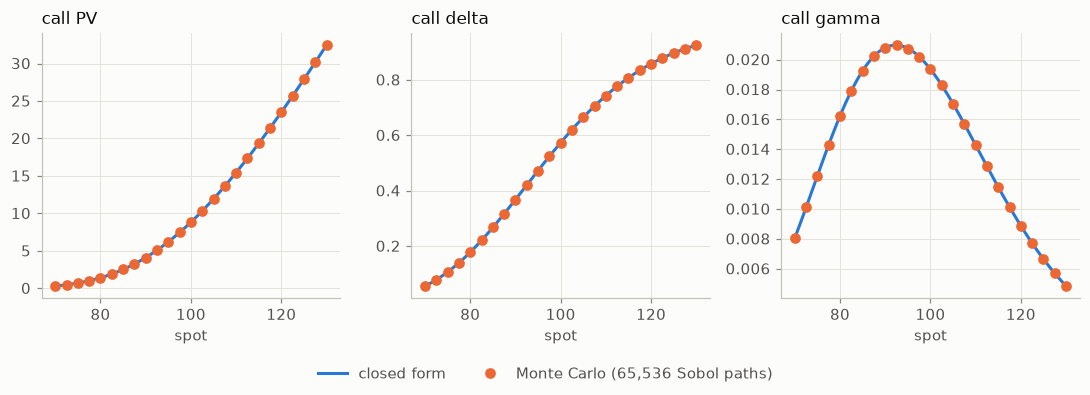

| spot | PV | delta | gamma（平滑 payoff） |
|:---|---:|---:|---:|
| 70.0 | 0.31060 | 0.05610 | 0.00806 |
| 85.0 | 2.51976 | 0.26737 | 0.01925 |
| 100.0 | 8.82621 | 0.57348 | 0.01935 |
| 115.0 | 19.33475 | 0.80749 | 0.01147 |
| 130.0 | 32.45594 | 0.92539 | 0.00485 |

In [6]:
ladder = jnp.linspace(70.0, 130.0, 25)
f_small, f_small_fuzzy = engine.pricer(2**16), engine.pricer(2**16, fuzzy=True)
pv_and_delta = jax.jit(jax.vmap(jax.value_and_grad(lambda s: f_small(with_spot(s))[0])))
gamma_curve = jax.jit(jax.vmap(jax.hessian(lambda s: f_small_fuzzy(with_spot(s))[0])))
pv_mc, delta_mc = pv_and_delta(ladder)
gamma_mc = gamma_curve(ladder)

fine = jnp.linspace(70.0, 130.0, 200)
closed = {
    "PV": jax.vmap(lambda s: bs(s)[0])(fine),
    "delta": jax.vmap(jax.grad(lambda s: bs(s)[0]))(fine),
    "gamma": jax.vmap(jax.hessian(lambda s: bs(s)[0]))(fine),
}
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, (name, mc) in zip(axes, [("PV", pv_mc), ("delta", delta_mc), ("gamma", gamma_mc)]):
    ax.plot(fine, closed[name], color=BLUE, label="closed form")
    ax.plot(ladder, mc, linestyle="none", marker="o", color=ORANGE, label="Monte Carlo (65,536 Sobol paths)")
    ax.set_title(f"call {name}")
    ax.set_xlabel("spot")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=2)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

idx = [0, 6, 12, 18, 24]
show_table(["spot", "PV", "delta", "gamma（平滑 payoff）"],
           [[f"{float(ladder[i]):.1f}", float(pv_mc[i]), float(delta_mc[i]), float(gamma_mc[i])] for i in idx], fmt="{:.5f}")

## 6. 更多 payoff 写法：亚式期权与延迟支付

- **亚式期权**：12 个月度观察日，payoff 是平均价减行权价。对整条路径做向量运算，比逐日期写循环更快；
- **延迟支付**：期权在 T = 1 确定、在 T + 0.5 支付，对应 DAL 的 `PAYS ... ON`。在 `SampleDef.discount_mats` 里声明支付日，模型就会在 `scenario.discounts` 里给出 P(t, T_pay)。BS 模型下这正好等于欧式价格再乘 e^(-0.5 r)。

In [7]:
monthly = tuple((k + 1) / 12.0 for k in range(12))


def asian_call(params, scenario, ctx):
    average = jnp.mean(scenario.spot)
    return jnp.maximum(average - params["script"]["STRIKE"], 0.0) / scenario.numeraire[-1]


asian = dj.PathProduct(timeline=monthly, payoff=asian_call, payoff_names=("asian",), script_params={"STRIKE": STRIKE})
asian_engine = dj.MonteCarloEngine(asian, model, dj.MonteCarloSettings(enable_aad=True, use_bb=True))
asian_result = asian_engine.value(N_PATHS)

PAY_DELAY = 0.5


def delayed_call(params, scenario, ctx):
    payoff = jnp.maximum(scenario.spot[-1] - params["script"]["STRIKE"], 0.0)
    return payoff * scenario.discounts[-1, 0] / scenario.numeraire[-1]


delayed = dj.PathProduct(
    timeline=(T,), payoff=delayed_call, sample_defs=(dj.SampleDef(discount_mats=(T + PAY_DELAY,)),), script_params={"STRIKE": STRIKE}
)
delayed_pv = dj.MonteCarloEngine(delayed, model).value(N_PATHS)["PV"]

show_table(["产品", "PV", "说明"], [
    ["亚式看涨（12 个月度观察日，Brownian bridge）", asian_result["PV"], f"d_spot = {asian_result['d_spot']:.5f}, d_vol = {asian_result['d_vol']:.5f}"],
    ["欧式看涨，T + 0.5 支付", delayed_pv, f"欧式 PV × e^(-0.5r) = {call * np.exp(-RATE * PAY_DELAY):.10f}"],
], fmt="{:.10f}")

| 产品 | PV | 说明 |
|:---|---:|---:|
| 亚式看涨（12 个月度观察日，Brownian bridge） | 5.3244121251 | d_spot = 0.54535, d_vol = 23.74080 |
| 欧式看涨，T + 0.5 支付 | 8.6956005314 | 欧式 PV × e^(-0.5r) = 8.6956005314 |

## 7. `path_payoffs`：逐路径诊断

`engine.path_payoffs(params, block_id, n_paths)` 返回一个块里每条路径的 id 和 payoff，可以用来计算标准误差、做自定义统计或者排查异常路径。
id 大于等于 `n_paths` 的是末块的填充路径，统计时要去掉。

In [8]:
layout = asian_engine.layout(N_PATHS)
asian_params = asian_engine.default_params()
block_values = jax.jit(lambda b: asian_engine.path_payoffs(asian_params, b, N_PATHS))
values = np.concatenate([np.asarray(block_values(b)[1][:, 0]) for b in range(layout.n_blocks)])[:N_PATHS]
mean, std_error = values.mean(), values.std(ddof=1) / np.sqrt(N_PATHS)
print(f"{layout.n_blocks} blocks of {layout.block_size} paths")
print(f"mean of path payoffs = {mean:.10f} (engine PV = {asian_result['PV']:.10f})")
print(f"standard error of an i.i.d. estimate = {std_error:.6f}")
print(f"share of paths finishing in the money: {np.mean(values > 0):.1%}")

32 blocks of 8192 paths
mean of path payoffs = 5.3244121251 (engine PV = 5.3244121251)
standard error of an i.i.d. estimate = 0.015644
share of paths finishing in the money: 50.7%


这里的标准误差按独立同分布样本计算，对伪随机数是正确的置信区间；Sobol 序列的实际误差通常小得多（见 notebook 01 的收敛图）。

## 小结

- `pricer` 只是一个函数：`jit`、`grad`、`jacrev`、`jacfwd`、`hessian`、`vmap` 可以按需要叠加；
- 参数 pytree 的每个叶子都可以求导，包括产品常量；
- 路径导数算二阶量时，payoff 至少要 C¹ 连续。